![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Tokenización de textos  

En este taller podrán poner en práctica sus conocimientos sobre preprocesamiento de texto (tokenización). El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos detección de toxicidad en comentarios

En este taller se usará el conjunto de datos de detección de toxicidad en comentarios de la base de datos de Kaggle. Cada observación es un comentario que tiene como variable objetivo (target) la probabilidad de ser un comentario tóxico. El objetivo es predecir la toxicidad de cada comentario. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/c/jigsaw-unintended-bias-in-toxicity-classification/data).

In [ ]:
# SUGERIDO: Descomenta la siguiente linea de código si requieres instalar las libreías básicas utilizadas en este notebook
# Si requieres incluir más librerías puedes agregarlas al archivo Semana 4\requirements.txt
#!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación librerías
import pandas as pd
import numpy as np
import scipy as sp
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# Carga de datos de archivos .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/Toxicity.zip')
df = df[['id','comment_text', 'target']]
df.head()

,id,comment_text,target
0,6101457,What are you talking about? What group do Pete...,0.0
1,5342103,"NO!, Let him, we need a Conservative government.",0.0
2,743361,"Perhaps he took the ""power out of the Cardinal...",0.2
3,551008,"As always, yours is dripping with sarcasm, whi...",0.0
4,865998,The dirty little secret is that the price rang...,0.3


In [4]:
df.shape

(541462, 3)

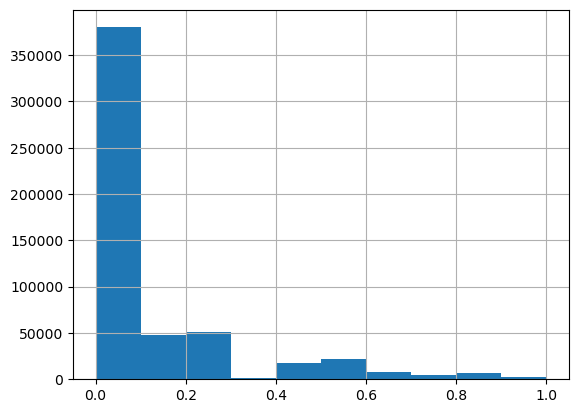

In [5]:
# Impresión histograma de variable de interés (y)
df.target.hist()
plt.show()

In [6]:
# Separación de variable de interés (y)
y = df.target
y.describe()

count    541462.000000
mean          0.102991
std           0.196979
min           0.000000
25%           0.000000
50%           0.000000
75%           0.166667
max           1.000000
Name: target, dtype: float64

In [7]:
# Separación de variables predictoras (X), solo se considera el texto de la noticia
X = df.comment_text

In [8]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Punto 1 - Tokenización con CountVectorizer

En la celda 1 creen y entrenen el modelo de regresión de su preferencia, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [9]:
vect_A = CountVectorizer(
    ngram_range=(1,2), #unigramas (palabras individuales) y bigramas
    max_features=50000

)
X_trainv = vect_A.fit_transform(X_train)
X_testv = vect_A.transform(X_test)

In [10]:
from sklearn.ensemble import RandomForestRegressor

clfRF = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    n_jobs=-1,
    random_state=0
)
clfRF.fit(X_trainv,y_train)
prediccionRF=clfRF.predict(X_testv)

In [11]:
from sklearn.metrics import mean_squared_error
mse1 = mean_squared_error(y_test, prediccionRF)
mse1

0.02894386895705347

## Punto 2 - Tokenización con CountVectorizer y trigramas

En la celda 2 creen y entrenen el mismo modelo de regresión del punto anterior (es decir si usaron un RandomForestRegresor usen nuevamente ese regresor), para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer **considerando trigramas** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [ ]:
vect_B = CountVectorizer(
    ngram_range=(3, 3),
    max_features=30000

)
X_trainB = vect_B.fit_transform(X_train)
X_testB = vect_B.transform(X_test)

In [ ]:
clfRFB = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    n_jobs=-1,
    random_state=0
)
clfRFB.fit(X_trainB,y_train)
prediccionRFB=clfRFB.predict(X_testB)
mse = mean_squared_error(y_test, prediccionRFB)
mse

0.038307221190785716

## Punto 3 - TfidfVectorizer

Investigen sobre la función TfidfVectorizer. En la celda de texto 3, expliquen en qué consiste esta técnica de tokenización (describanla y expliquen su funcionamiento) y cúales son las ventajas o deventajas de su uso al compararlo con la función CountVectorizer.

### función TfidfVectorizer
TF: Term Frequency. Mide cuantas veces aparece una palabra en un texto dado, para ello se calcula la razón entre la cantidad de veces que aparece la palabra en un texto y la cantidad de palabras que tiene el texto.

$$ TF(t,d) = \frac{f_{t,d}}{\sum_{t' \in d} f_{t',d}} $$

IDF: Inverse Document Frequency: Evalua el peso que tiene una palabra dado varios textos mientras que le da mayor peso a las palabras que son raras o que no se encuentra en varios texto, para ello se calcula con el logaritmo de la división entre la cantidad de textos sobre el número de veces que aparece la palabra.

$$ IDF(t) = \log \left( \frac{N}{df_t} \right) $$

Por último, por el resultado que da en TF e IDF se realiza la multiplicación, este resultado es la asignación de peso que se da por las palabras.

$$ TF\text{-}IDF(t,d) = TF(t,d) \times IDF(t) $$

Lo anterior TF-IDF genera ese balance donde permite de alguna manera darle la asignación de peso importante a cada palabra, donde si son muy comunes entonces tiene peso muy bajo y si aparece muy pocas veces, tienen mayor peso.

Al compararlo con CountVectorizer tenemos como ventajas de la ponderación, donde TF-IDF a las palabras que aparecen mucho son castigados, aquellas palabras como "el", "de", "y" tendrían mayor castigos que CountVectorizer todos tienen la misma ponderación por lo que los tendría en cuenta lo cual se consideraría desventaja, aunque también se podría hacer con stop word pero sería manual, y habría que desarrollarlo.

Como desventaja es que estas técnicas no entienden semántica o contexto, es decir, que si aparece una palabra como carro o auto, para nosotros como humanos es facil entenderlo para estos, no es posible igualarlo, porque para ellos esas palabras son diferentes.


## Punto 4 - Tokenización con TfidfVectorizer

En la celda 4 creen y entrenen el mismo modelo de regresión del primer punto, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Procesen los comentarios con la función **TfidfVectorizer** y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [10]:
# Celda 4
vect_TFIDF = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=50000
)
X_train_idf = vect_TFIDF.fit_transform(X_train)
X_test_idf = vect_TFIDF.transform(X_test)

In [13]:
from sklearn.ensemble import RandomForestRegressor

clfRF_TFIDF = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    n_jobs=-1,
    random_state=0
)
clfRF_TFIDF.fit(X_train_idf,y_train)
prediccionRF_TFIDF=clfRF_TFIDF.predict(X_test_idf)

In [14]:
from sklearn.metrics import mean_squared_error
mse_TFIDF = mean_squared_error(y_test, prediccionRF_TFIDF)
mse_TFIDF

0.02893381043648486

## Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos y comenten cómo el preprocesamiento de texto afecta el desempeño.

In [ ]:
# Celda 5 Código para graficos y tablas comparativas


In [ ]:
### Punto 5.1 - Comparación y análisis de resultados
